In [18]:
library(patchwork)
library(tidyverse)

theme_set(theme_classic())
options(repr.plot.res = 200)

DATA_SOURCE_URL = 'https://www.envidata.cz/projects/faktaOKlimatu/export.php?type=raw&ID='
STATION_ID = 'B2BTUR01'
COLOUR_TMIN = 'dodgerblue4'
COLOUR_TMAX = 'firebrick'

month.abb <- stringi::stri_datetime_symbols('cs_CZ', width = 'abb')$Month
month.len <- c(31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31)

download_and_cache <- function(station_id) {
  file_path <- paste0('../data/chmi/', station_id, '.csv')
  if (!file.exists(file_path)) {
    url <- paste0(DATA_SOURCE_URL, station_id)
    download.file(url, file_path, quiet = TRUE)
  }
  read_csv(file_path, show_col_types = FALSE)
}

# Otázky na které hledáme odpovědi:

- Jaká je přirozená proměnlivost (= variabilita) klimatu v daném místě? Jaké teploty jsou pro dané období v roce běžné (průměr, K25, K75) a jaké vyjímečné?
- Jak se mění klimatické podmínky mění v průběhu klimatické změny – tedy jak se mění co je běžné a co je vyjímečné počasí? Jak se zvyšují frekvence výzkytu vyjimečně teplých / vyjímečně studených dní?
- Jak srovnávat extrémní události (vedra, zimy) s jinými místy na planetě? Jinak řečeno: lze srovnat variability klimatu třeba s Kanadou, Jižní Afrikou, nebo Singapurem? Když bylo v Kanadě naměřeno +50 °C – jaký teplotní extrém by tomu odpovídal u nás?
- Jaké klimatické podmínky můžeme očekávat v budoucnosti – zejména co se týče výskytu extrémně teplých dní?
- Jak atribuovat extrémy ke klimatické změně?

### Označení veličin

Jako vstupní data máme průměrné denní teploty, nejvyšší denní teploty a nejnižší denní teploty pro určité místo – $T(s, y, d)$, $T_{\rm max}(s, y, d)$, $T_{\rm min}(s, y, d)$, kde $s$ označuje stanici, $y$ rok měření a $d$ den v roce.

Teplotní normály pro dané místo a dny vztahujeme k referenčnímu období 1961–1990:
- $T^{\rm norm}(s, d) = \frac{1}{30} \sum_{y=1961}^{1990} T(s, y, d)$ je normál průměrné denní teploty.
- $T_{\rm max}^{\rm norm}(s, d) = \frac{1}{30} \sum_{y=1961}^{1990} T_{\rm max}(s, y, d)$ je normál nejvyšší denní teploty.
- $T_{\rm min}^{\rm norm}(s, d) = \frac{1}{30} \sum_{y=1961}^{1990} T_{\rm min}(s, y, d)$ je normál nejnižší denní teploty.

Kvůli vzorkovací chybě dále používáme pro teplotní normály zhlazení 15 denním klouzavým průměrem:
- $NT(s, d) = \frac{1}{15} \sum_{\delta=d-7}^{d+7} T^{\rm norm}(s, \delta)$ a podobně pro $NT_{\rm max}$ a $NT_{\rm min}$. (Sčítání a odčítání je "modulo" počet dní v roce, tj. $365 + 1 = 1$ a $5 - 7 = 363$.)

Stejně tak značíme a používáme kvantily teploty pro dané místo a den:
- $K_{25} T(s, d)$ označuje takovou teplotu, že 25 % hodnot průměrné denní teploty pro daný den $d$ v referenčním období bylo na stanici $s$ menších než tato hodnota. Jinak řečeno, v 7–8 letech z 30letého období byla průměrná denní teplota v den $d$ pod touto hodnotou.
- Teplotní anomálie (TA) pro dané místo a den jsou rozdílem měřené hodnoty v daném roce a dni od normálu. (Přesněji vyhlazeného normálu.)
- Teplotní anomálii opět definujeme pro průměry, maxima i minima:
  $TA(s, y, d) = T(s, y, d) - NT(s, d)$  
  $TA_{\rm max}(s, y, d) = T_{\rm max}(s, y, d) - NT_{\rm max}(s, d)$  
  $TA_{\rm min}(s, y, d) = T_{\rm min}(s, y, d) - NT_{\rm min}(s, d)$

Nicméně protože se ukazuje, že mezi $TA$, $TA_{\rm max}$ a $TA_{\rm min}$ je velmi dobrá korelace, používáme dále pro kvantifikaci variability klimatu pouze $TA$.

In [19]:
# Načtení and předzpracování dat.
weather_data <- download_and_cache(STATION_ID) %>%
  rename(year = Y, month = M, day = D, tavg = TAVG, tmin = TMIN, tmax = TMAX) %>%
  filter(1961 <= year, year <= 2020,
         # Zahodíme 29. únory.
         !(month == 2 & day == 29))

# Výpočet prostých a vyhlazených normálů pro každý den v roce.
daily_normals_1961_1990 <- filter(weather_data, 1961 <= year, year < 1991) %>%
  group_by(month, day) %>%
  summarise(day_mean = mean(tavg),
            day_min  = mean(tmin),
            day_max  = mean(tmax),
            .groups  = 'drop') %>%
  mutate(
    day_mean_smooth = stats::filter(day_mean,
                                    filter   = rep(1/15, 15),
                                    circular = TRUE),
    day_min_smooth = stats::filter(day_min,
                                   filter   = rep(1/15, 15),
                                   circular = TRUE),
    day_max_smooth = stats::filter(day_max,
                                   filter   = rep(1/15, 15),
                                   circular = TRUE)) %>%
  mutate(ix = 1:365, .before = 'month')

# Výpočet denních teplotních anomální pro průměrnou, minimální a maximální teplotu.
anomalies <-
  inner_join(weather_data, daily_normals_1961_1990, by = c('month', 'day')) %>%
  mutate(anomaly_smooth     = tavg - day_mean_smooth,
         anomaly_min_smooth = tmin - day_min_smooth,
         anomaly_max_smooth = tmax - day_max_smooth)

### Jak souvisí nejnižší a nejvyšší denní teploty s průměrnou denní teplotou?

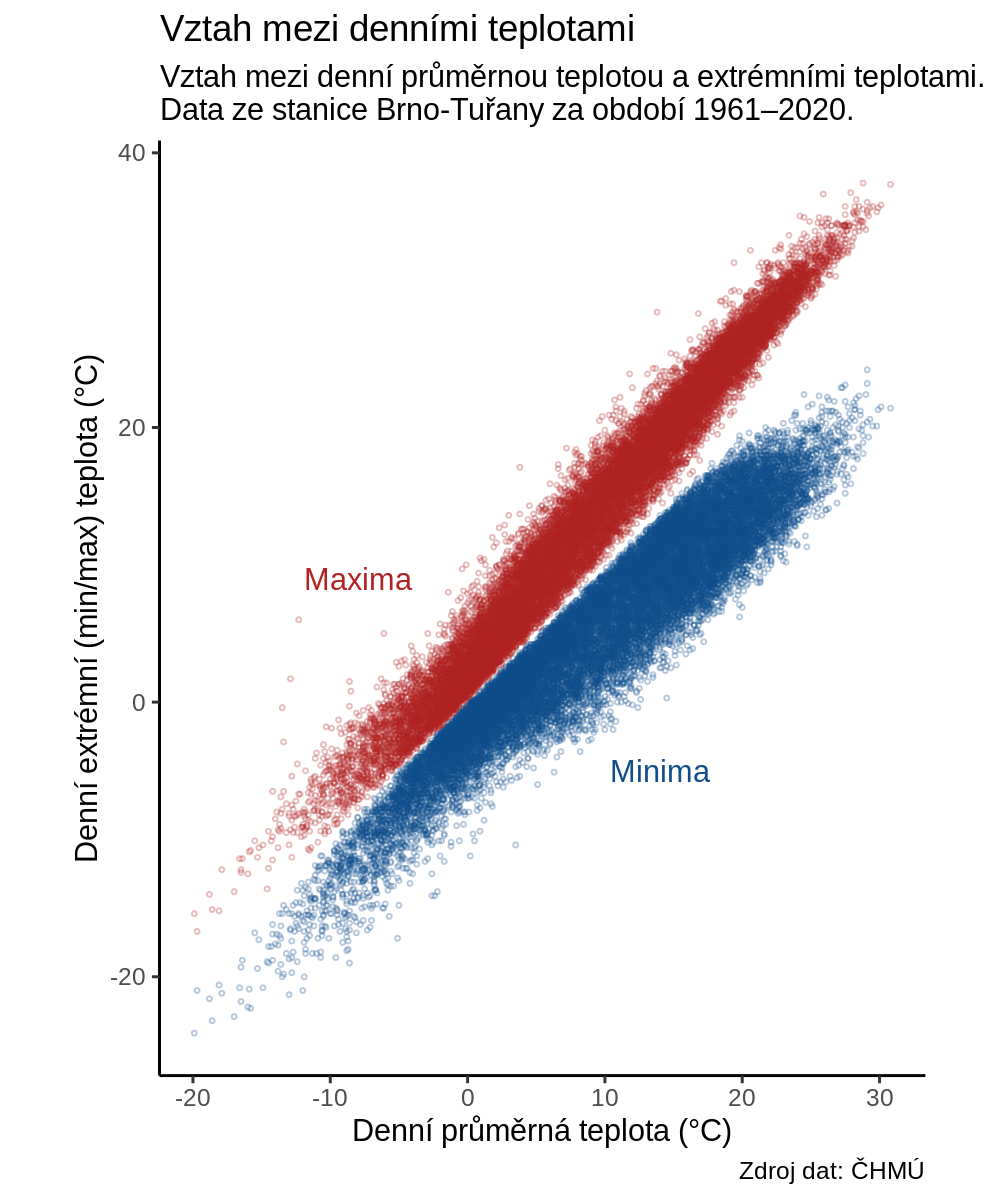

In [34]:
options(repr.plot.width = 5, repr.plot.height = 6)
ggplot(weather_data, aes(x = tavg)) +
  geom_point(aes(y = tmin, colour = 'min'),
             shape = 1,
             size = .5) +
  geom_point(aes(y = tmax, colour = 'max'),
             shape = 1,
             size = .5) +
  annotate('text', 14, -5, label = 'Minima', colour = COLOUR_TMIN) +
  annotate('text', -8, 9, label = 'Maxima', colour = COLOUR_TMAX) +
  scale_colour_manual(values = adjustcolor(c(COLOUR_TMAX, COLOUR_TMIN), .3),
                      guide  = 'none') +
  coord_fixed() +
  labs(title    = 'Vztah mezi denními teplotami',
       subtitle = str_c('Vztah mezi denní průměrnou teplotou a extrémními teplotami.\n',
                        'Data ze stanice Brno-Tuřany za období 1961–2020.'),
       caption  = 'Zdroj dat: ČHMÚ',
       x        = 'Denní průměrná teplota (°C)',
       y        = 'Denní extrémní (min/max) teplota (°C)')

In [22]:
select(weather_data, tavg, tmin, tmax) %>%
  as.matrix() %>%
  cor() %>% round(2) %>% .[1,]

tavg tmin tmax 
1.00 0.95 0.98

Pearsonova korelace mezi denní průměrnou a minimální teplotou je 0,95. Korelace mezi denní průměrnou a maximální teplotou je 0,98.

### Jak souvisí anomálie nejvyšší a nejnižší denní teploty s anomálií průměrné denní teploty?

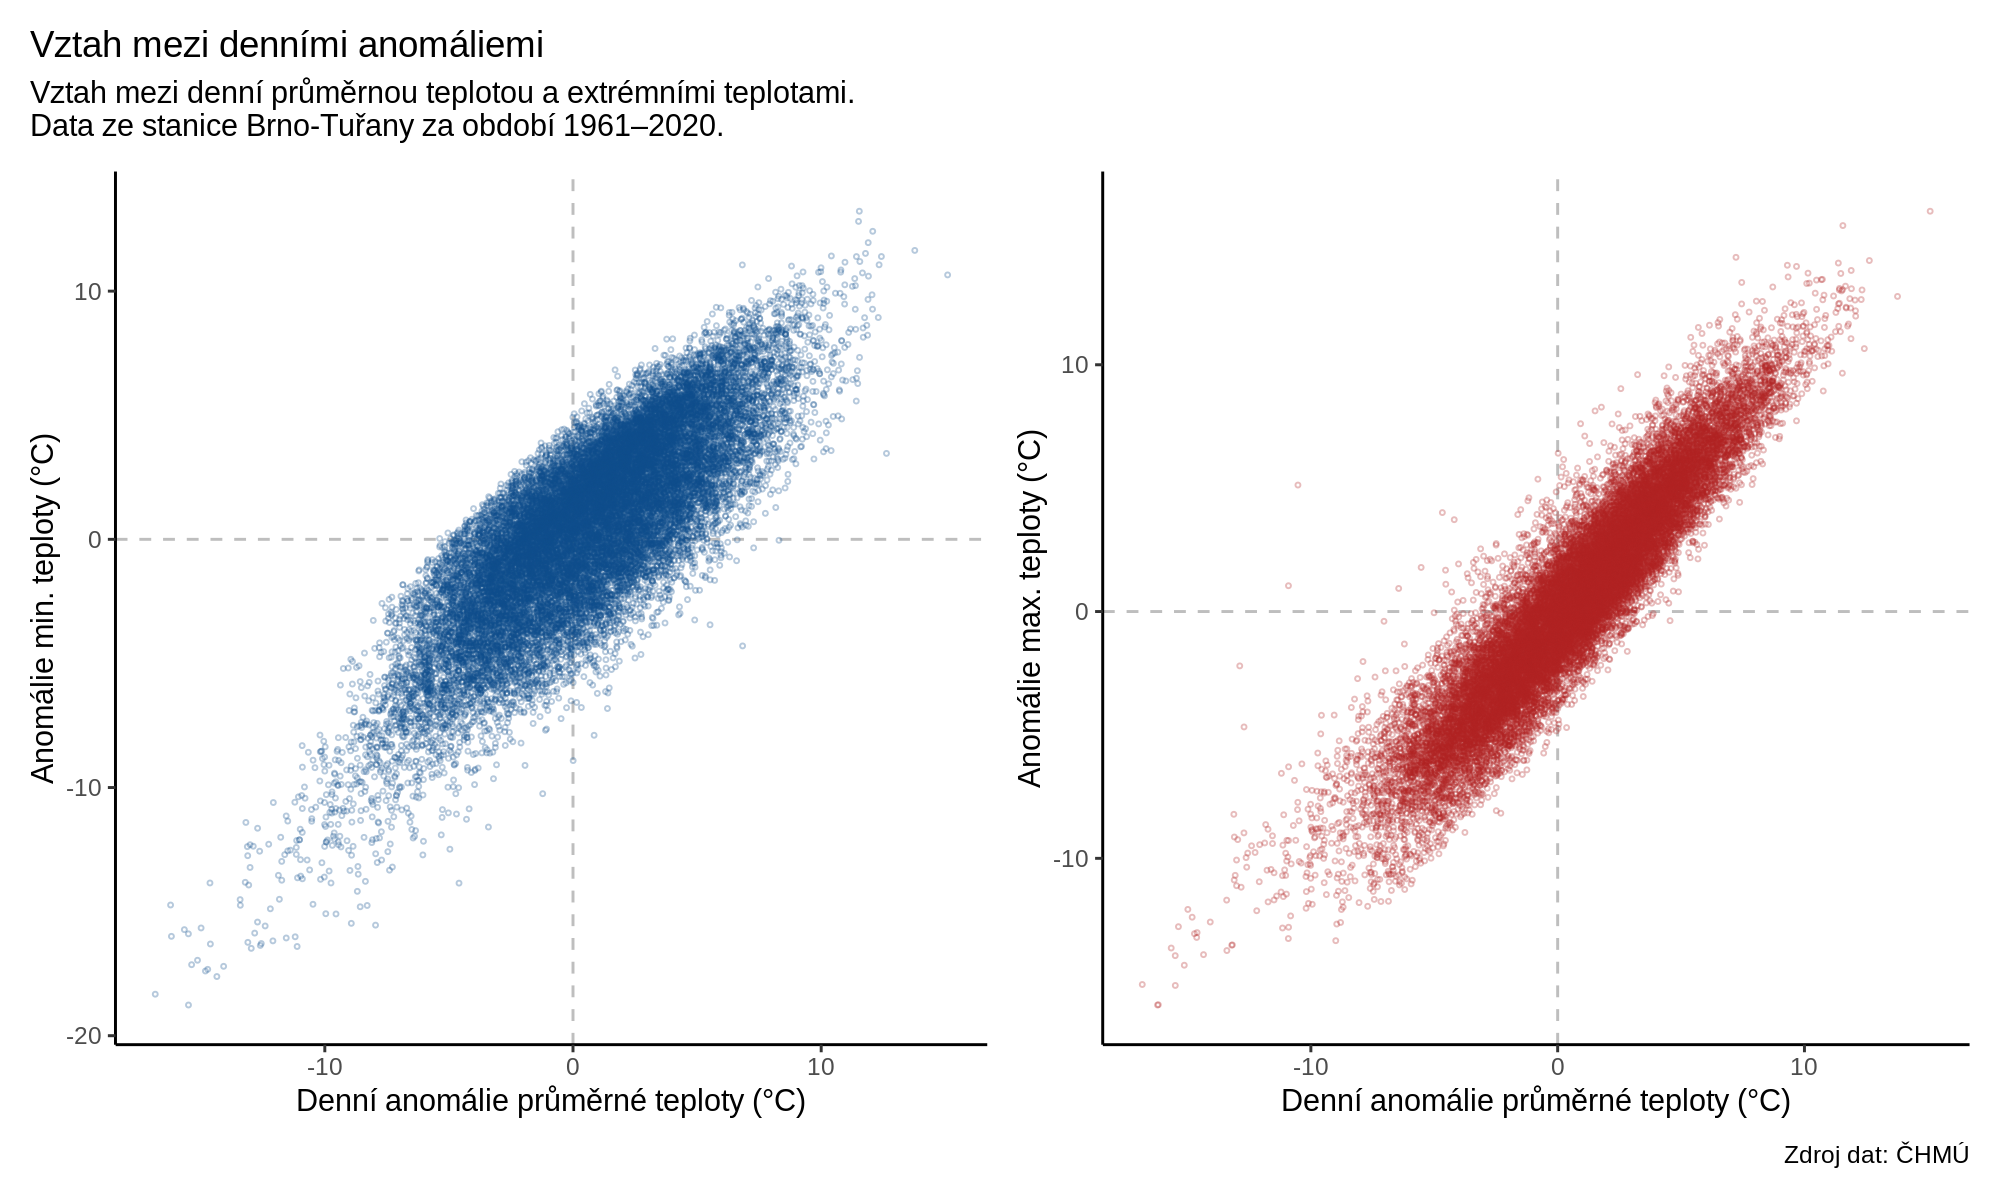

In [29]:
p_anom_corr_min <- ggplot(anomalies, aes(anomaly_smooth, anomaly_min_smooth)) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
  geom_vline(xintercept = 0, linetype = 'dashed', color = 'grey') +
  geom_point(shape = 1,
             size = .5,
             colour = adjustcolor(COLOUR_TMIN, .3)) +
  coord_fixed() +
  labs(x = 'Denní anomálie průměrné teploty (°C)',
       y = 'Anomálie min. teploty (°C)')

p_anom_corr_max <- ggplot(anomalies, aes(anomaly_smooth, anomaly_max_smooth)) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
  geom_vline(xintercept = 0, linetype = 'dashed', color = 'grey') +
  geom_point(shape = 1,
             size = .5,
             colour = adjustcolor(COLOUR_TMAX, .3)) +
  coord_fixed() +
  labs(x = 'Denní anomálie průměrné teploty (°C)',
       y = 'Anomálie max. teploty (°C)')

options(repr.plot.width = 10, repr.plot.height = 6)
p_anom_corr_min + p_anom_corr_max +
  plot_annotation(
    title    = 'Vztah mezi denními anomáliemi',
    subtitle = str_c('Vztah mezi denní průměrnou teplotou a extrémními teplotami.\n',
                     'Data ze stanice Brno-Tuřany za období 1961–2020.'),
    caption  = 'Zdroj dat: ČHMÚ')

In [23]:
select(anomalies,
       aavg = anomaly_smooth,
       amin = anomaly_min_smooth,
       amax = anomaly_max_smooth) %>%
  as.matrix() %>%
  cor() %>% round(2) %>% .[1,]

aavg amin amax 
1.00 0.81 0.93

Pearsonova korelace mezi denní anomálií průměrné a minimální teploty je 0,81. Korelace mezi denní anomálií průměrné a maximální teploty je 0,93.

### Závisí variabilita klimatu na různých ročních obdobích nebo je víceméně stejná v průběhu celého roku?

Následující vizualizace zobrazuje varibilitu teplotních anomálií v průběhu roku. Na levé straně je naše referenční období 1961–1990, na pravé straně je následující třicetiletí, 1991–2020. Variability v zimních měsících je viditelně o něco větší...

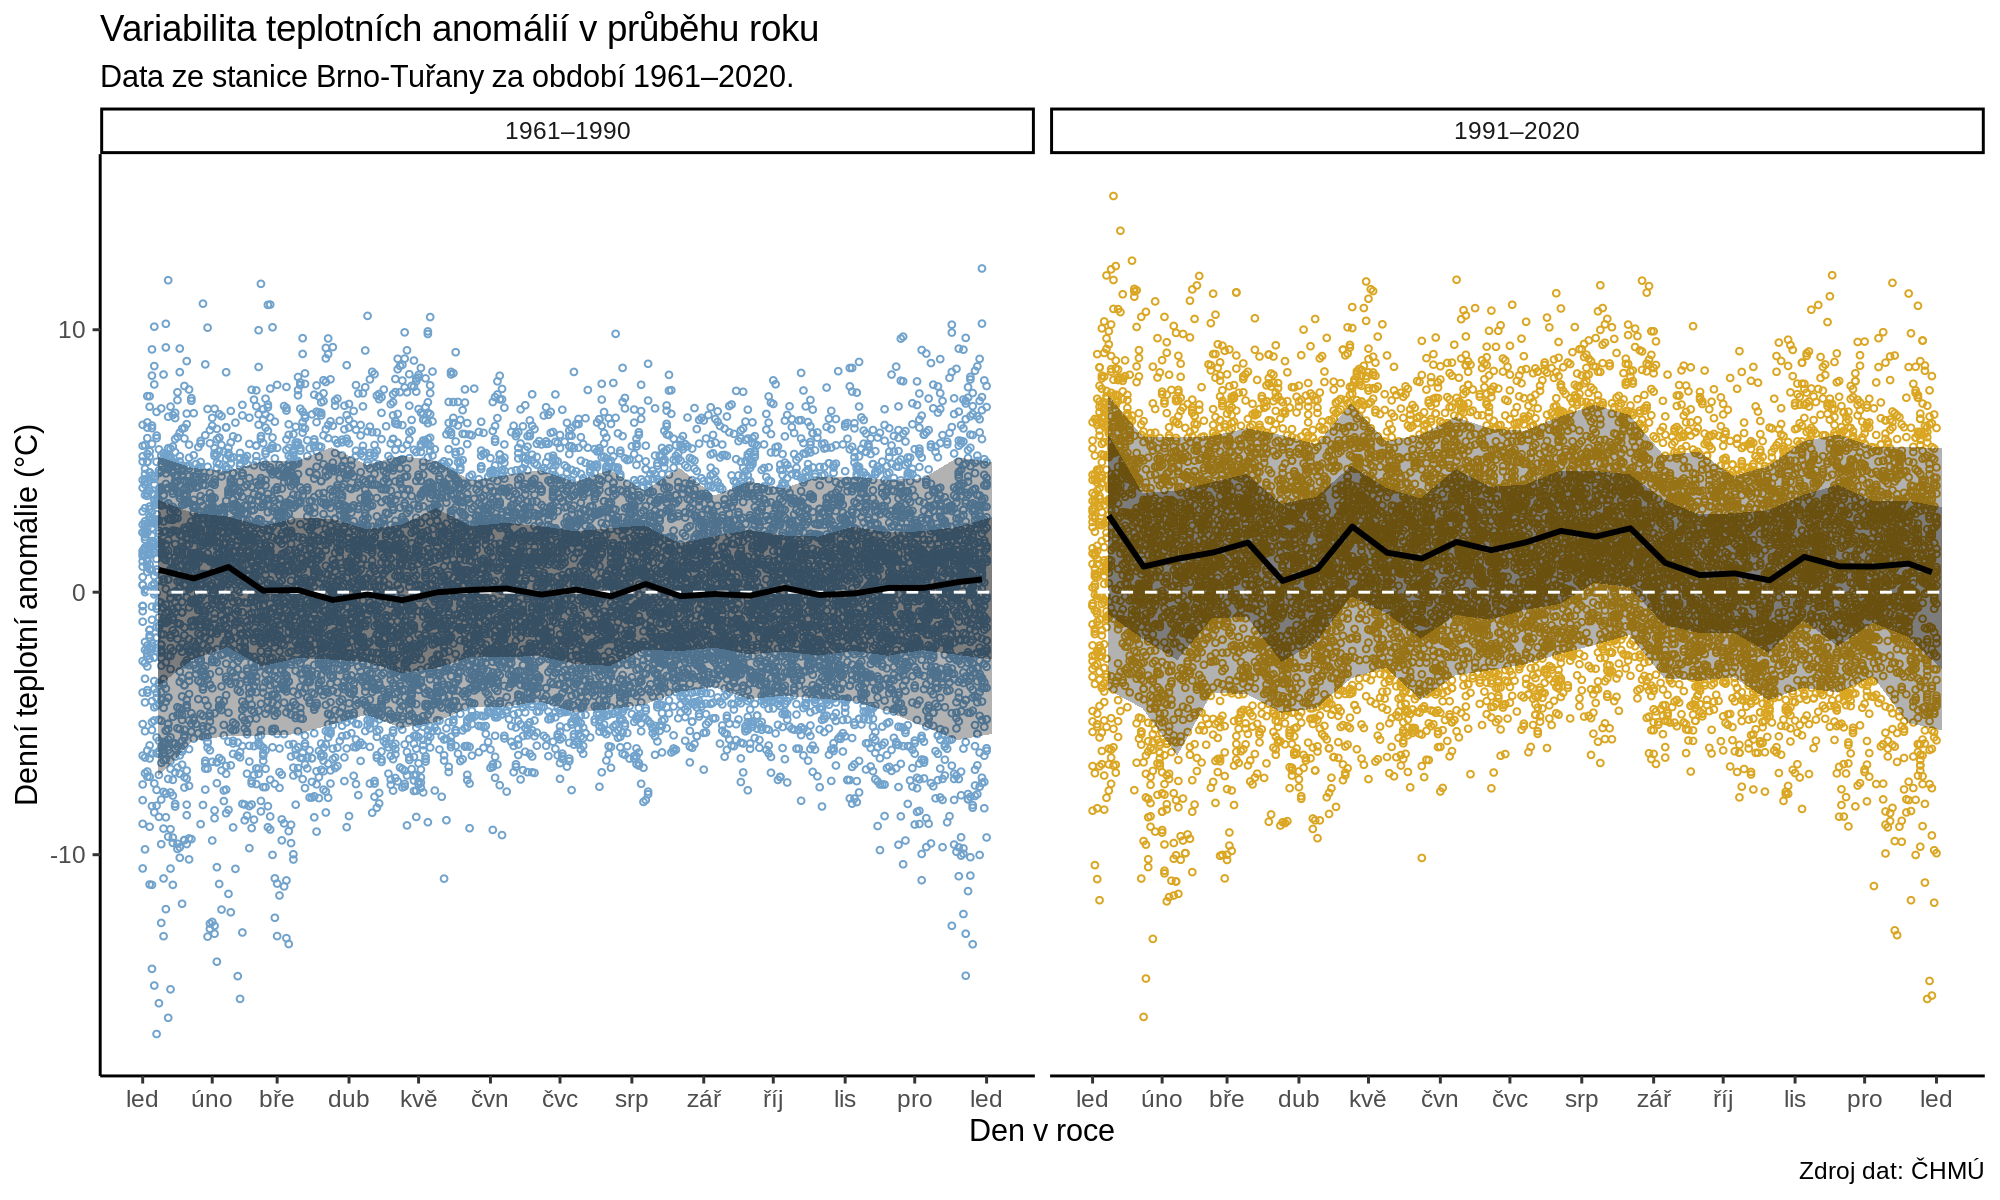

In [30]:
mutate(anomalies,
       period = factor(year > 1990, labels = c('1961–1990', '1991–2020'))) %>%
  ggplot(aes(ix, anomaly_smooth)) +
  # Body pro jednotlivá denní měření.
  geom_point(aes(colour = period), size = .8, shape = 1) +
  # Pruh pro 50% centrální kvantily – 15denní bins.
  stat_summary_bin(geom     = 'ribbon',
                   fun.min  = ~ quantile(.x, .25),
                   fun.max  = ~ quantile(.x, .75),
                   binwidth = 15,
                   fill     = adjustcolor('black', .3)) +
  # Pruh pro 80% centrální kvantily – 15denní bins.
  stat_summary_bin(geom     = 'ribbon',
                   fun.min  = ~ quantile(.x, .1),
                   fun.max  = ~ quantile(.x, .9),
                   binwidth = 15,
                   fill     = adjustcolor('black', .3)) +
  # Přerušovaná čára pro nulovou anomálii.
  geom_hline(yintercept = 0, linetype = 'dashed', colour = 'white') +
  # Černá čára pro medián anomálie v 15denním období.
  geom_line(data = ~ mutate(.x, bin = cut_interval(ix, length = 15)) %>%
              group_by(period, bin) %>%
              summarise(ix             = mean(range(ix)),
                        anomaly_smooth = median(anomaly_smooth),
                        .groups        = 'drop'),
            size = 1) +
  scale_x_continuous('Den v roce',
                     breaks = c(1, cumsum(month.len)),
                     labels = c(month.abb, month.abb[1])) +
  scale_colour_manual('Období',
                      values = c('#70a2cb', 'goldenrod'),
                      guide  = 'none') +
  facet_grid(cols = vars(period)) +
  labs(title    = 'Variabilita teplotních anomálií v průběhu roku',
       subtitle = 'Data ze stanice Brno-Tuřany za období 1961–2020.',
       caption  = 'Zdroj dat: ČHMÚ',
       y        = 'Denní teplotní anomálie (°C)')

Další text here...

### Je teplotní anomálie dobře korelovaná na celém území ČR? Neboli můžeme očekávat, že když je TA v Praze +10 °C, bude podobná i na Lysé Hoře?

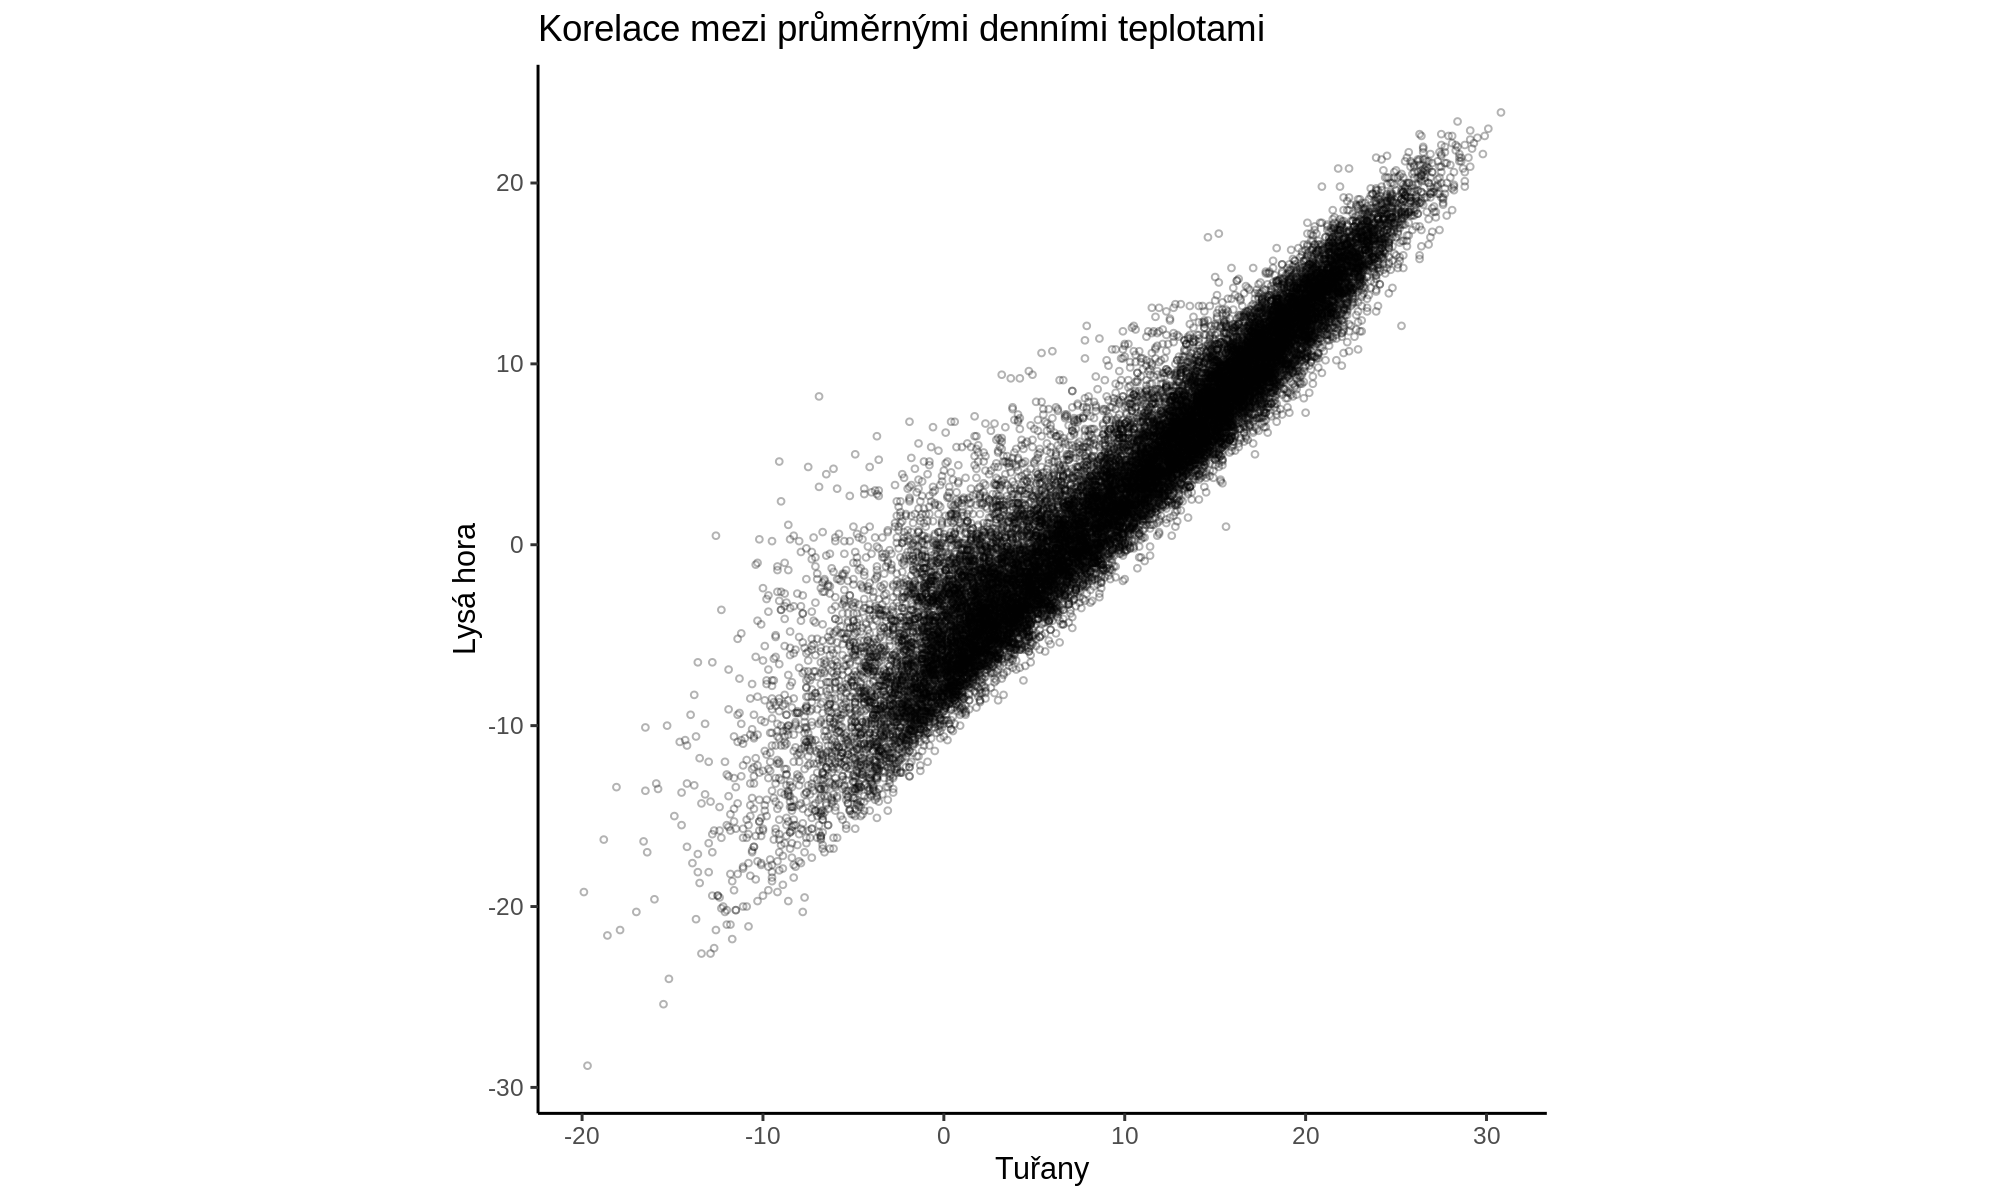

In [32]:
# Data pro Lysou horu.
wd2 <- download_and_cache('O1LYSA01') %>%
  rename(year = Y, month = M, day = D, tavg = TAVG, tmin = TMIN, tmax = TMAX) %>%
  filter(1961 <= year, year <= 2020,
         # Zahodíme 29. únory.
         !(month == 2 & day == 29)) %>%
  mutate(station = 'lysa_hora') %>%
  rbind(mutate(weather_data, station = 'turany'))

select(wd2, station, year, month, day, tavg) %>%
  pivot_wider(year:day, names_from = station, values_from = tavg) %>%
  ggplot(aes(turany, lysa_hora)) +
  geom_point(shape = 1, size = .8, alpha = .3) +
  coord_fixed() +
  labs(title = 'Korelace mezi průměrnými denními teplotami', x = 'Tuřany', y = 'Lysá hora')